In [1]:
import matplotlib.pyplot as plt
from src.controllers.pid import PIDController
from src.config.models.dual_rotor_beam_drone import DualRotorBeamDroneModel, DualRotorBeamDroneConfig


In [ ]:
drone_config = DualRotorBeamDroneConfig(
    length=0.3,
    mass=0.5,
    motor_base_thrust=5.0,
    max_thrust=15.0,
    min_thrust=0.0,
    gravity=9.81,
    angular_damping=0.0
)
drone = DualRotorBeamDroneModel(config=drone_config)

In [3]:
target = 0.0
current_angle = -25.0
angular_velocity = 0.0

time = 10.0
dt = 0.01

kp = 0.40
ki = 0.0
kd = 0.06

def run_simulation(kp, ki, kd, dt=0.01, time=10.0):
    total_steps = int(time / dt)
    pid = PIDController(kp=kp, ki=ki, kd=kd, dt=dt, max_integral_error=10.0)
    pid.reset()

    current_angle = -25.0
    angular_velocity = 0.0

    target_angle_history = []
    current_angle_history = []
    time_history = []

    for step in range(total_steps):
        current_time = step * dt

        if current_time == 3.0:
            current_angle = 15.0

        current_angle = drone.get_current_angle(current_angle)

        pid_output = pid.compute(target, current_angle)

        next_angle, next_angular_velocity, angular_acc, control = drone.step(
            angle=current_angle,
            angular_velocity=angular_velocity,
            pid_output=pid_output,
            dt=dt
        )

        angular_velocity = next_angular_velocity
        current_angle = next_angle

        target_angle_history.append(target)
        current_angle_history.append(current_angle)
        time_history.append(current_time)

    return time_history, target_angle_history, current_angle_history

time_history, target_angle_history, current_angle_history = run_simulation(kp, ki, kd, dt=dt, time=time)

In [4]:
def plot_results(time_history, target_angle_history, current_angle_history, title, text=None, save_path=None):
    plt.figure(figsize=(10, 5))
    plt.plot(time_history, target_angle_history, label='Target Angle (degrees)')
    plt.plot(time_history, current_angle_history, label='Current Angle (degrees)')
    plt.axvline(
            x=3,
            color="r",
            linestyle="--",
            label="Disturbance line",
        )
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (degrees)')
    plt.title(title)
    
    # Render text box if text is passed
    if text:
        box_props = dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', edgecolor='gray', alpha=0.85)

        plt.gca().text(
            0.98, 0.05, text, 
            transform=plt.gca().transAxes, 
            verticalalignment='bottom',
            horizontalalignment='right',
            fontsize=10, 
            bbox=box_props
        )
    
    # Move legend to upper right to prevent overlapping with the text box
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        save_path = pathlib.Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

stats_info = (
    f"  Kp = {kp:.2f}\n"
    f"  Ki = {ki:.2f}\n"
    f"  Kd = {kd:.2f}"
)

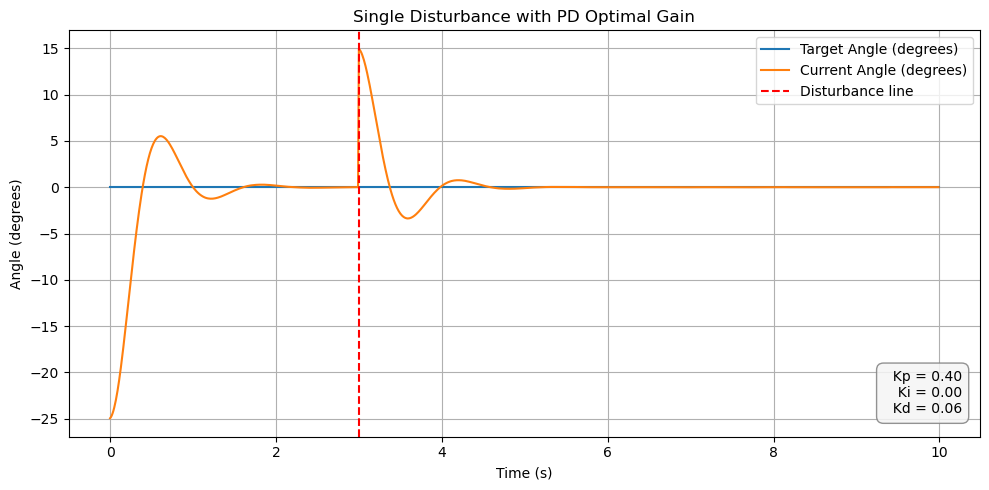

In [5]:
plot_results(time_history, target_angle_history, current_angle_history, "Single Disturbance with PD Optimal Gain", text=stats_info)